In [4]:
# Cell 1: check GPU
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TF version: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# Cell 2 (replacement): download dataset using the new access token
!pip install -q -U kaggle        # new tokens need kaggle CLI >= 1.8.0

import os, getpass
os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Paste Kaggle token: ")

!kaggle datasets download -d azaemon/preprocessed-ct-scans-for-covid19 -p /content/data --unzip
!ls /content/data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 3.9 MB/s eta 0:00:00
Paste Kaggle token: ··········
Dataset URL: https://www.kaggle.com/datasets/azaemon/preprocessed-ct-scans-for-covid19
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.59G/3.59G [00:24<00:00, 154MB/s]

'Original CT Scans'  'Preprocessed CT scans'


In [4]:
!du -sh /content/data

3.8G	/content/data


In [6]:
# Cell 3: explore folder structure (don't assume — look)
import os

DATA_DIR = "/content/data"

for root, dirs, files_ in os.walk(DATA_DIR):
    depth = root.replace(DATA_DIR, "").count(os.sep)
    if depth <= 2:
        print(f"{'  '*depth}{os.path.basename(root)}/  ({len(files_)} files)")

data/  (0 files)
  Preprocessed CT scans/  (0 files)
    pCT/  (4001 files)
    nCT/  (9979 files)
    NiCT/  (5705 files)
  Original CT Scans/  (0 files)
    pCT/  (4001 files)
    nCT/  (9979 files)
    NiCT/  (5705 files)


In [7]:
# Cell 4: point to ONE folder only
IMG_ROOT = "/content/data/Preprocessed CT scans"

In [8]:
# Cell 5: rebuild the image table
import pandas as pd
from pathlib import Path

exts = {".png", ".jpg", ".jpeg"}
rows = [{"path": str(p), "label": p.parent.name}
        for p in Path(IMG_ROOT).rglob("*") if p.suffix.lower() in exts]
df = pd.DataFrame(rows)

print("Total images:", len(df))        # expect 19685
print(df["label"].value_counts())      # expect nCT 9979, NiCT 5705, pCT 4001

Total images: 19685
label
nCT     9979
NiCT    5705
pCT     4001
Name: count, dtype: int64


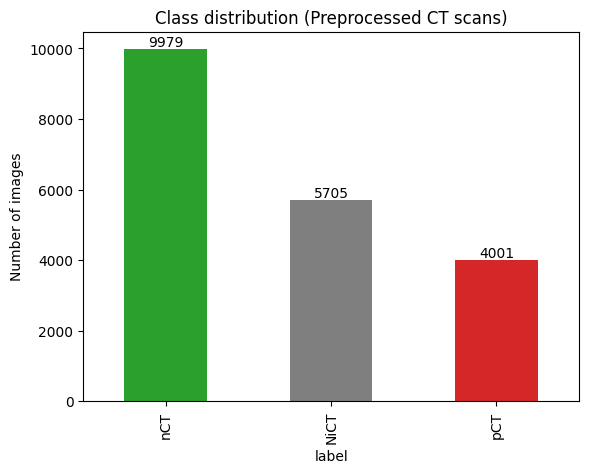

In [9]:
# Cell 6: class distribution (fixed colors: one color per class)
import matplotlib.pyplot as plt

counts = df["label"].value_counts()
palette = {"nCT": "#2ca02c", "pCT": "#d62728", "NiCT": "#7f7f7f"}
ax = counts.plot(kind="bar", color=[palette[c] for c in counts.index])
ax.set_title("Class distribution (Preprocessed CT scans)")
ax.set_ylabel("Number of images")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.show()

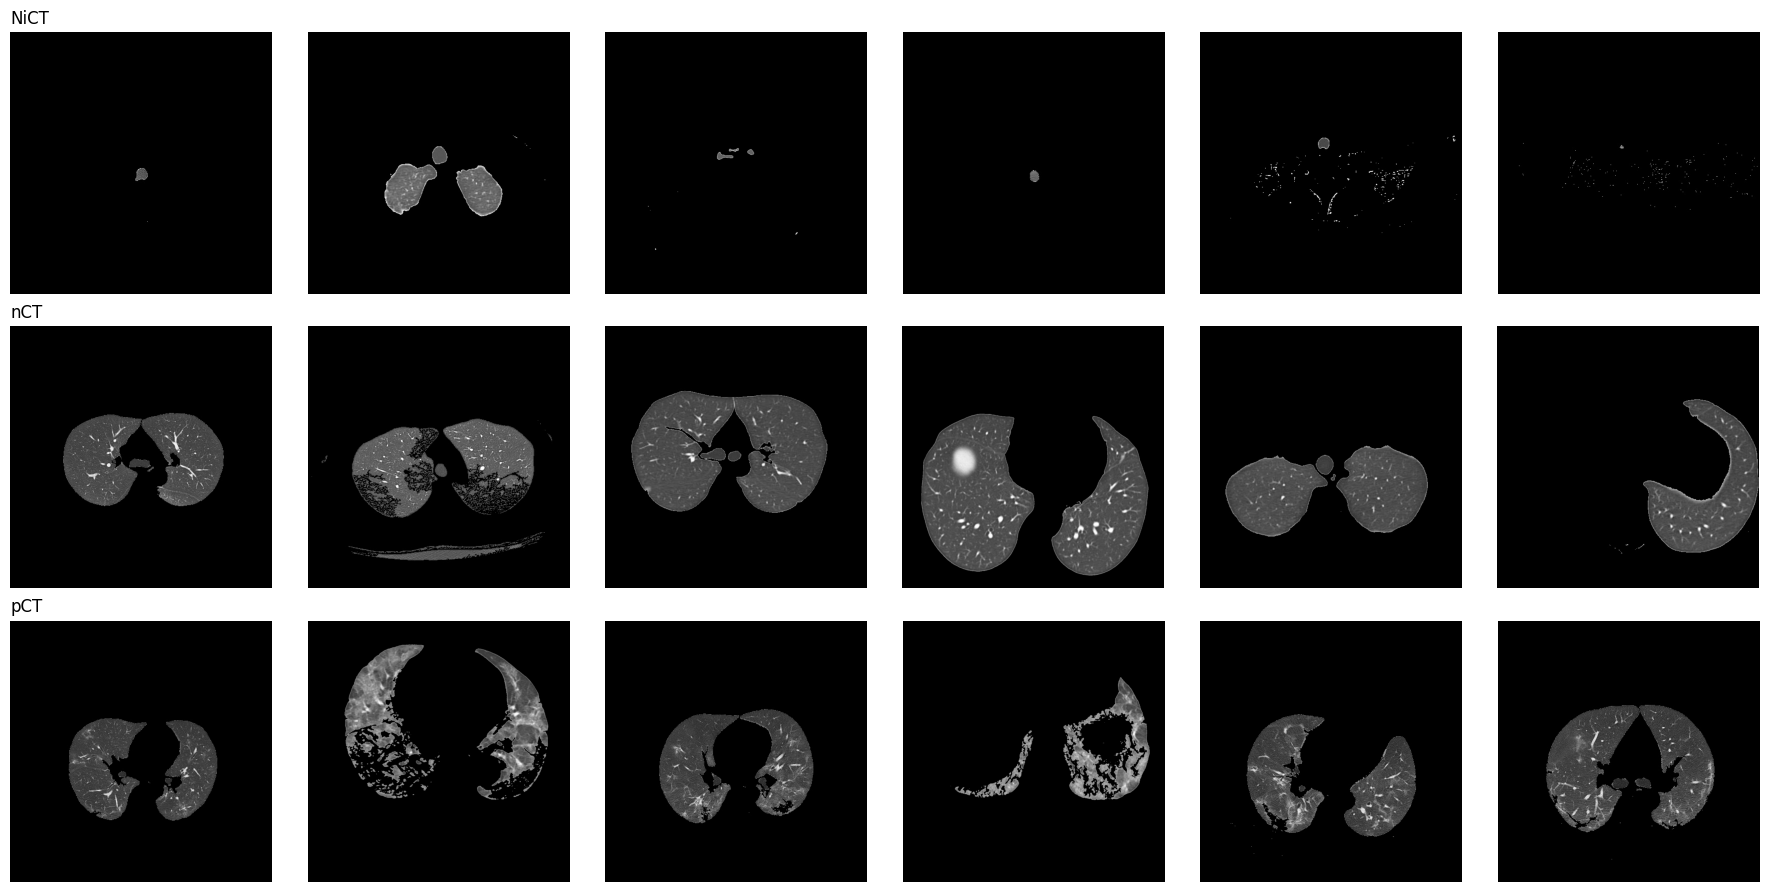

In [10]:
# Cell 7: visualize random CT images per class
import random
from PIL import Image

classes = sorted(df["label"].unique())
n = 6
fig, axes = plt.subplots(len(classes), n, figsize=(3*n, 3*len(classes)))
axes = axes.reshape(len(classes), n)

for r, cls in enumerate(classes):
    sample = df[df.label == cls].sample(n, random_state=42)
    for c, path in enumerate(sample.path):
        axes[r, c].imshow(Image.open(path), cmap="gray")
        axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_title(cls, loc="left", fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# Cell 8: image sizes and color modes on the preprocessed folder
from PIL import Image
import numpy as np

sample = df.sample(500, random_state=0)
sizes, modes = [], []
for p in sample.path:
    with Image.open(p) as im:
        sizes.append(im.size)
        modes.append(im.mode)

print("Sizes:", pd.Series(sizes).value_counts().to_dict())
print("Color modes:", pd.Series(modes).value_counts().to_dict())
arr = np.array(Image.open(sample.path.iloc[0]))
print("dtype:", arr.dtype, "| min:", arr.min(), "| max:", arr.max())

Sizes: {(512, 512): 349, (575, 575): 82, (1211, 1211): 63, (574, 574): 6}
Color modes: {'L': 500}
dtype: uint8 | min: 0 | max: 135


In [12]:
# Cell 9: duplicates, including duplicates labeled with DIFFERENT classes
import hashlib

hashes = {}
for p, lbl in zip(df.path, df.label):
    with open(p, "rb") as f:
        h = hashlib.md5(f.read()).hexdigest()
    hashes.setdefault(h, []).append((p, lbl))

dupes = {h: v for h, v in hashes.items() if len(v) > 1}
conflict = {h: v for h, v in dupes.items() if len({l for _, l in v}) > 1}
print("Duplicate groups:", len(dupes))
print("Groups with conflicting labels:", len(conflict))

# Clean index: drop label-conflict groups entirely, keep one copy of the rest
keep = []
for h, v in hashes.items():
    if h in conflict:
        continue
    keep.append({"path": v[0][0], "label": v[0][1]})
df_clean = pd.DataFrame(keep)
print("After cleaning:", len(df_clean))
print(df_clean["label"].value_counts())

df_clean.to_csv("/content/clean_index.csv", index=False)

Duplicate groups: 59
Groups with conflicting labels: 1
After cleaning: 19555
label
nCT     9949
NiCT    5605
pCT     4001
Name: count, dtype: int64


In [13]:
# Cell 10: setup + reload cleaned index (re-run Cells 1-2 first if the session reset)
import pandas as pd, numpy as np, os, random
import tensorflow as tf
from google.colab import drive

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/covid_ct_project"
os.makedirs(SAVE_DIR, exist_ok=True)

df = pd.read_csv("/content/clean_index.csv")
df = df[df.label.isin(["nCT", "pCT"])].reset_index(drop=True)   # binary task
df["y"] = (df.label == "pCT").astype(int)                       # nCT=0, pCT=1
print(df.label.value_counts())

Mounted at /content/drive
label
nCT    9949
pCT    4001
Name: count, dtype: int64


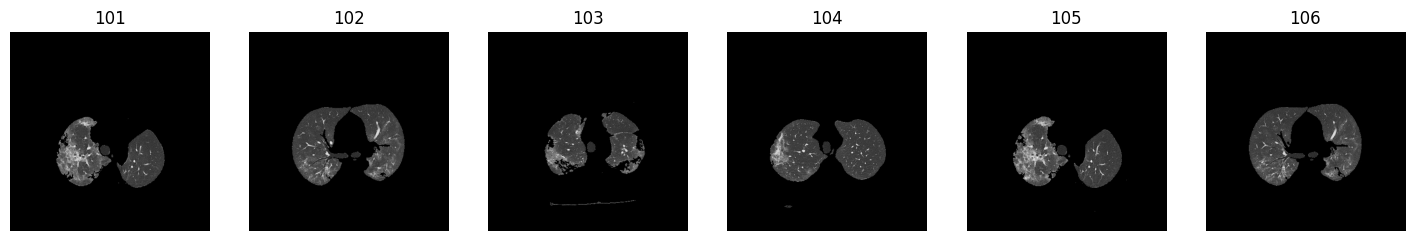

In [14]:
# Cell 11: leakage check — do neighboring file numbers look like neighboring slices?
import re
from PIL import Image
import matplotlib.pyplot as plt

def num(p): return int(re.findall(r"(\d+)\.", os.path.basename(p))[0])
df["fileno"] = df.path.apply(num)

pc = df[df.label == "pCT"].sort_values("fileno")
start = pc.fileno.iloc[100]
sub = pc[pc.fileno >= start].head(6)
fig, ax = plt.subplots(1, 6, figsize=(18, 3))
for a, (p, n) in zip(ax, zip(sub.path, sub.fileno)):
    a.imshow(Image.open(p), cmap="gray"); a.set_title(n); a.axis("off")
plt.show()

In [15]:
# Cell 12: pixel intensity statistics across many images
s = df.sample(300, random_state=SEED)
maxes = [np.array(Image.open(p)).max() for p in s.path]
print("Max pixel value across 300 images -> min:", min(maxes),
      "| median:", int(np.median(maxes)), "| max:", max(maxes))

Max pixel value across 300 images -> min: 151 | median: 255 | max: 255


In [16]:
# Cell 13: stratified train / val / test split (70 / 15 / 15)
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df.y, random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df.y, random_state=SEED)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s} n={len(d):5d} | pCT share = {d.y.mean():.3f}")

# Safety check: no image appears in two splits
assert not (set(train_df.path) & set(val_df.path))
assert not (set(train_df.path) & set(test_df.path))
assert not (set(val_df.path) & set(test_df.path))
print("No overlap between splits ✔")

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    d.to_csv(f"{SAVE_DIR}/{name}.csv", index=False)

train n= 9765 | pCT share = 0.287
val   n= 2092 | pCT share = 0.287
test  n= 2093 | pCT share = 0.287
No overlap between splits ✔


In [17]:
# Cell 14: class weights (from TRAIN only)
from sklearn.utils.class_weight import compute_class_weight

w = compute_class_weight("balanced", classes=np.array([0, 1]), y=train_df.y)
class_weight = {0: float(w[0]), 1: float(w[1])}
print(class_weight)

{0: 0.7011056863871339, 1: 1.7431274544805426}


In [18]:
# Cell 15: tf.data pipeline (load → resize → 3 channels → augment train only)
IMG_SIZE = 224
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=1, expand_animations=False)   # grayscale
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), antialias=True)     # resize
    img = tf.image.grayscale_to_rgb(img)                                 # 1 → 3 channels
    img = tf.cast(img, tf.float32)                                       # stays 0–255
    return img, tf.cast(label, tf.float32)

augment = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.04),            # about ±14 degrees
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.1),
], name="augment")

def make_ds(frame, training):
    ds = tf.data.Dataset.from_tensor_slices((frame.path.values, frame.y.values))
    if training:
        ds = ds.shuffle(len(frame), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (augment(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_ds(train_df, training=True)
val_ds   = make_ds(val_df,   training=False)
test_ds  = make_ds(test_df,  training=False)

x, y = next(iter(train_ds))
print("Batch shape:", x.shape, "| dtype:", x.dtype, "| labels:", y.shape)

Batch shape: (32, 224, 224, 3) | dtype: <dtype: 'float32'> | labels: (32,)


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input [[[[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  ...

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]]] with name 'keras_tensor' and path ''. Expected shape (224, 224, 3), but input has incompatible shape (1, 224, 224, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

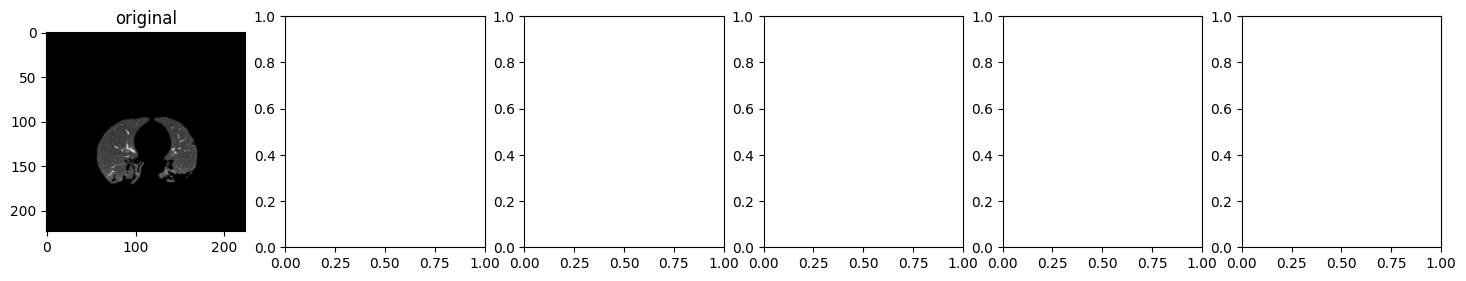

In [21]:
# Cell 16: see what augmentation does
import matplotlib.pyplot as plt

path = train_df[train_df.y == 1].path.iloc[0]
orig, _ = load_image(path, 1)

fig, ax = plt.subplots(1, 6, figsize=(18, 3))
ax[0].imshow(orig.numpy().astype("uint8")); ax[0].set_title("original")
for i in range(1, 6):
    aug = augment(tf.expand_dims(orig, 0), training=True)[0]
    ax[i].imshow(np.clip(aug.numpy(), 0, 255).astype("uint8"))
    ax[i].set_title(f"aug {i}")
for a in ax: a.axis("off")
plt.show()

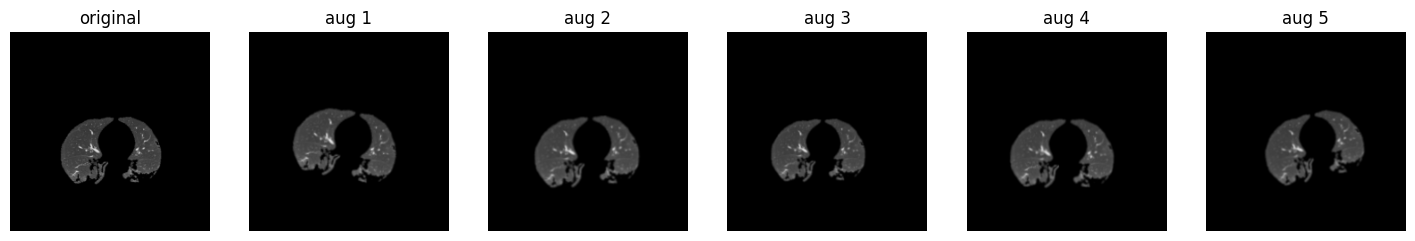

In [22]:
# Cell 16
import matplotlib.pyplot as plt

path = train_df[train_df.y == 1].path.iloc[0]
orig, _ = load_image(path, 1)

fig, ax = plt.subplots(1, 6, figsize=(18, 3))
ax[0].imshow(orig.numpy().astype("uint8")); ax[0].set_title("original")
for i in range(1, 6):
    aug = augment(orig, training=True)          # single image, no batch dimension
    ax[i].imshow(np.clip(aug.numpy(), 0, 255).astype("uint8"))
    ax[i].set_title(f"aug {i}")
for a in ax: a.axis("off")
plt.show()

In [23]:
# Cell 17: similarity-grouped split
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import StratifiedGroupKFold

# 1. fingerprints (embeddings) for every image
base = tf.keras.applications.MobileNetV2(
    include_top=False, weights="imagenet", pooling="avg", input_shape=(224, 224, 3))
prep = tf.keras.applications.mobilenet_v2.preprocess_input

all_ds = (tf.data.Dataset.from_tensor_slices((df.path.values, df.y.values))
          .map(load_image, num_parallel_calls=AUTOTUNE)
          .batch(64)
          .map(lambda x, y: prep(x))
          .prefetch(AUTOTUNE))
emb = base.predict(all_ds, verbose=1)
emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)
print("Embeddings:", emb.shape)          # (13950, 1280)

# 2. group look-alike images
df["group"] = MiniBatchKMeans(n_clusters=400, random_state=SEED,
                              batch_size=2048, n_init=3).fit_predict(emb)
print("Largest groups:", df.group.value_counts().head(5).to_dict())

# 3. split by group, keeping class balance (7 folds: 1 test, 1 val, 5 train ≈ 71/14/14)
sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
folds = list(sgkf.split(df, df.y, groups=df.group))
test_idx, val_idx = folds[0][1], folds[1][1]
train_idx = np.setdiff1d(np.arange(len(df)), np.concatenate([test_idx, val_idx]))

train_g, val_g, test_g = df.iloc[train_idx], df.iloc[val_idx], df.iloc[test_idx]
for name, d in [("train", train_g), ("val", val_g), ("test", test_g)]:
    print(f"{name:5s} n={len(d):5d} | pCT share = {d.y.mean():.3f} | groups = {d.group.nunique()}")

# 4. safety checks: no group shared between splits
assert not (set(train_g.group) & set(test_g.group))
assert not (set(train_g.group) & set(val_g.group))
assert not (set(val_g.group) & set(test_g.group))
print("No group overlap between splits ✔")

for name, d in [("train", train_g), ("val", val_g), ("test", test_g)]:
    d.to_csv(f"{SAVE_DIR}/{name}_grouped.csv", index=False)

# 5. rebuild weights + datasets from the grouped split
w = compute_class_weight("balanced", classes=np.array([0, 1]), y=train_g.y)
class_weight = {0: float(w[0]), 1: float(w[1])}
print("class_weight:", class_weight)

train_ds = make_ds(train_g, training=True)
val_ds   = make_ds(val_g,   training=False)
test_ds  = make_ds(test_g,  training=False)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
218/218 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step
Embeddings: (13950, 1280)
Largest groups: {10: 124, 238: 100, 1: 89, 96: 86, 252: 81}
train n= 9940 | pCT share = 0.289 | groups = 291
val   n= 2058 | pCT share = 0.251 | groups = 56
test  n= 1952 | pCT share = 0.316 | groups = 53
No group overlap between splits ✔
class_weight: {0: 0.7027714932126696, 1: 1.7329149232914924}


In [24]:
# Cell 18: reload everything needed (safe to run after a session reset;
# first re-run Cells 1-2, 10 and 15)
import json
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

train_g = pd.read_csv(f"{SAVE_DIR}/train_grouped.csv")
val_g   = pd.read_csv(f"{SAVE_DIR}/val_grouped.csv")
test_g  = pd.read_csv(f"{SAVE_DIR}/test_grouped.csv")

w = compute_class_weight("balanced", classes=np.array([0, 1]), y=train_g.y)
class_weight = {0: float(w[0]), 1: float(w[1])}

train_ds = make_ds(train_g, training=True)
val_ds   = make_ds(val_g,   training=False)
print(len(train_g), len(val_g), len(test_g), class_weight)

9940 2058 1952 {0: 0.7027714932126696, 1: 1.7329149232914924}


In [25]:
# Cell 19: model builder (one function for all three architectures)
def build_model(name):
    inputs = keras.Input((224, 224, 3))

    if name == "mobilenetv2":
        x = layers.Rescaling(1/127.5, offset=-1)(inputs)           # → [-1, 1]
        base = keras.applications.MobileNetV2(
            include_top=False, weights="imagenet", input_shape=(224, 224, 3))
    elif name == "resnet50":
        x = layers.Normalization(mean=[103.939, 116.779, 123.68],
                                 variance=[1., 1., 1.])(inputs)    # mean subtraction
        base = keras.applications.ResNet50(
            include_top=False, weights="imagenet", input_shape=(224, 224, 3))
    elif name == "efficientnetb0":
        x = inputs                                                  # preprocessing is built in
        base = keras.applications.EfficientNetB0(
            include_top=False, weights="imagenet", input_shape=(224, 224, 3))
    else:
        raise ValueError(name)

    base.trainable = False                       # Stage 1: frozen
    x = base(x, training=False)                  # keep BatchNorm in inference mode
    x = layers.GlobalAveragePooling2D()(x)       # feature maps → one vector
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)   # P(COVID)
    return keras.Model(inputs, outputs, name=name), base


def compile_model(model, lr):
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 keras.metrics.AUC(name="auc"),
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall")])

m, b = build_model("mobilenetv2")
print("Total params:", f"{m.count_params():,}", "| frozen base layers:", len(b.layers))

Total params: 2,259,265 | frozen base layers: 154


In [27]:
# Cell 20: two-stage training function
def train_model(name, head_epochs=8, ft_epochs=12, unfreeze=30):
    model, base = build_model(name)
    ckpt_path = f"{SAVE_DIR}/{name}_best.keras"
    checkpoint = keras.callbacks.ModelCheckpoint(
        ckpt_path, monitor="val_auc", mode="max", save_best_only=True)

    def callbacks():   # fresh early-stopping/LR callbacks per stage, shared checkpoint
        return [checkpoint,
                keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                              patience=4, restore_best_weights=True),
                keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                                                  patience=2, min_lr=1e-7)]

    # Stage 1: train only the new head
    compile_model(model, 1e-3)
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=head_epochs,
                   class_weight=class_weight, callbacks=callbacks())

    # Stage 2: unfreeze the top layers, keep BatchNorm frozen, tiny learning rate
    base.trainable = True
    for layer in base.layers[:-unfreeze]:
        layer.trainable = False
    for layer in base.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    compile_model(model, 1e-5)
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=ft_epochs,
                   class_weight=class_weight, callbacks=callbacks())

    hist = {k: h1.history[k] + h2.history[k] for k in h1.history}
    with open(f"{SAVE_DIR}/{name}_history.json", "w") as f:
        json.dump(hist, f)

    best = keras.models.load_model(ckpt_path)       # best epoch across both stages
    print(f"\n{name} — validation metrics (best checkpoint):")
    res = best.evaluate(val_ds, return_dict=True, verbose=0)
    print({k: round(v, 4) for k, v in res.items()})
    return best, hist

In [28]:
# Cell 21: SMOKE TEST — 1 epoch per stage, just to confirm nothing crashes (~3-5 min)
_ = train_model("mobilenetv2", head_epochs=1, ft_epochs=1)

311/311 ━━━━━━━━━━━━━━━━━━━━ 71s 192ms/step - accuracy: 0.8448 - auc: 0.9219 - loss: 0.3602 - precision: 0.6930 - recall: 0.8295 - val_accuracy: 0.9121 - val_auc: 0.9684 - val_loss: 0.2002 - val_precision: 0.8429 - val_recall: 0.7988 - learning_rate: 0.0010
311/311 ━━━━━━━━━━━━━━━━━━━━ 72s 191ms/step - accuracy: 0.9304 - auc: 0.9802 - loss: 0.1805 - precision: 0.8494 - recall: 0.9222 - val_accuracy: 0.9286 - val_auc: 0.9809 - val_loss: 0.1514 - val_precision: 0.8585 - val_recall: 0.8569 - learning_rate: 1.0000e-05

mobilenetv2 — validation metrics (best checkpoint):
{'accuracy': 0.9286, 'auc': 0.9809, 'loss': 0.1514, 'precision': 0.8585, 'recall': 0.8569}


In [30]:
# Cell 22: real training, one model per cell (run them one at a time)
mobilenet, h_mob = train_model("mobilenetv2", unfreeze=30)
resnet, h_res = train_model("resnet50", unfreeze=30)
effnet, h_eff = train_model("efficientnetb0", unfreeze=20)

Epoch 1/8
311/311 ━━━━━━━━━━━━━━━━━━━━ 66s 181ms/step - accuracy: 0.8373 - auc: 0.9147 - loss: 0.3741 - precision: 0.6806 - recall: 0.8218 - val_accuracy: 0.9193 - val_auc: 0.9613 - val_loss: 0.2245 - val_precision: 0.8369 - val_recall: 0.8433 - learning_rate: 0.0010
Epoch 2/8
311/311 ━━━━━━━━━━━━━━━━━━━━ 46s 148ms/step - accuracy: 0.9060 - auc: 0.9659 - loss: 0.2423 - precision: 0.8050 - recall: 0.8898 - val_accuracy: 0.9242 - val_auc: 0.9720 - val_loss: 0.2085 - val_precision: 0.8172 - val_recall: 0.8994 - learning_rate: 0.0010
Epoch 3/8
311/311 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.9217 - auc: 0.9732 - loss: 0.2119 - precision: 0.8339 - recall: 0.9100 - val_accuracy: 0.9198 - val_auc: 0.9692 - val_loss: 0.1956 - val_precision: 0.8284 - val_recall: 0.8588 - learning_rate: 0.0010
Epoch 4/8
311/311 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.9242 - auc: 0.9756 - loss: 0.2018 - precision: 0.8369 - recall: 0.9160 - val_accuracy: 0.9189 - val_auc: 0.9665 - val_loss: 0.20

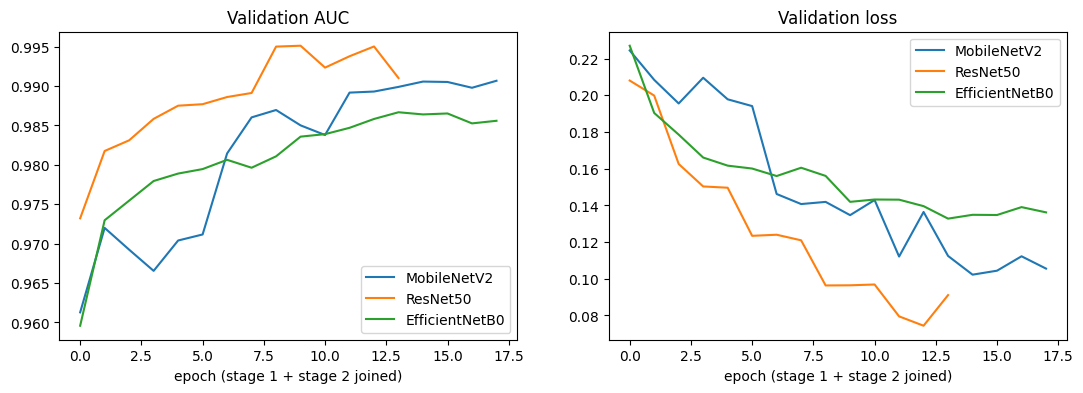

In [31]:
# Cell 23: training curves for all three
import matplotlib.pyplot as plt

hists = {"MobileNetV2": h_mob, "ResNet50": h_res, "EfficientNetB0": h_eff}
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for name, h in hists.items():
    ax[0].plot(h["val_auc"], label=name)
    ax[1].plot(h["val_loss"], label=name)
ax[0].set_title("Validation AUC"); ax[1].set_title("Validation loss")
for a in ax:
    a.set_xlabel("epoch (stage 1 + stage 2 joined)"); a.legend()
plt.show()

In [32]:
# Cell 24: comparison table (validation set — the test set stays untouched until Phase 4)
rows = []
for name, m in [("MobileNetV2", mobilenet), ("ResNet50", resnet), ("EfficientNetB0", effnet)]:
    r = m.evaluate(val_ds, return_dict=True, verbose=0)
    rows.append({"model": name, "params (M)": round(m.count_params()/1e6, 1),
                 "val AUC": round(r["auc"], 4), "val precision": round(r["precision"], 4),
                 "val recall": round(r["recall"], 4), "val accuracy": round(r["accuracy"], 4)})
comparison = pd.DataFrame(rows)
comparison.to_csv(f"{SAVE_DIR}/model_comparison_val.csv", index=False)
comparison

,model,params (M),val AUC,val precision,val recall,val accuracy
0,MobileNetV2,2.3,0.9907,0.9329,0.9149,0.9621
1,ResNet50,23.6,0.9951,0.9084,0.9594,0.9655
2,EfficientNetB0,4.1,0.9867,0.8662,0.8762,0.9349


In [33]:
# Cell 25: predictions on validation and test sets (test_ds is NOT shuffled, so order is preserved)
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_curve)

RES_DIR = f"{SAVE_DIR}/results"
os.makedirs(RES_DIR, exist_ok=True)

val_ds  = make_ds(val_g,  training=False)
test_ds = make_ds(test_g, training=False)

# if the session was reset, reload first:
# mobilenet = keras.models.load_model(f"{SAVE_DIR}/mobilenetv2_best.keras")  (same for resnet, effnet)
models = {"ResNet50": resnet, "MobileNetV2": mobilenet, "EfficientNetB0": effnet}

yv, yt = val_g.y.values, test_g.y.values
preds = {}
for name, m in models.items():
    pv = m.predict(val_ds,  verbose=0).ravel()
    pt = m.predict(test_ds, verbose=0).ravel()
    assert len(pv) == len(val_g) and len(pt) == len(test_g)
    preds[name] = (pv, pt)
print("Predictions done:", list(preds))

Predictions done: ['ResNet50', 'MobileNetV2', 'EfficientNetB0']


In [34]:
# Cell 26: metrics at the default threshold (0.5) and at a threshold tuned on VALIDATION
def best_f1_threshold(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    return float(thr[np.argmax(f1[:-1])])

def metrics_at(y, p, t):
    pred = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {"threshold": round(t, 3),
            "accuracy": accuracy_score(y, pred),
            "precision": precision_score(y, pred),
            "recall": recall_score(y, pred),
            "specificity": tn / (tn + fp),
            "f1": f1_score(y, pred),
            "auc": roc_auc_score(y, p),
            "TP": tp, "FP": fp, "TN": tn, "FN": fn}

rows = []
for name, (pv, pt) in preds.items():
    t_tuned = best_f1_threshold(yv, pv)                    # chosen on validation only
    for label, t in [("0.5", 0.5), ("val-tuned", t_tuned)]:
        r = metrics_at(yt, pt, t)
        rows.append({"model": name, "threshold_type": label, **r})

results = pd.DataFrame(rows).round(4)
results.to_csv(f"{RES_DIR}/test_metrics.csv", index=False)
results

,model,threshold_type,threshold,accuracy,precision,recall,specificity,f1,auc,TP,FP,TN,FN
0,ResNet50,0.5,0.500,0.9590,0.9098,0.9659,0.9558,0.9370,0.9944,595,59,1277,21
1,ResNet50,val-tuned,0.694,0.9606,0.9285,0.9481,0.9663,0.9382,0.9944,584,45,1291,32
2,MobileNetV2,0.5,0.500,0.9472,0.9867,0.8442,0.9948,0.9099,0.9923,520,7,1329,96
3,MobileNetV2,val-tuned,0.530,0.9467,0.9885,0.8409,0.9955,0.9088,0.9923,518,6,1330,98
4,EfficientNetB0,0.5,0.500,0.9206,0.9832,0.7614,0.9940,0.8582,0.9852,469,8,1328,147
5,EfficientNetB0,val-tuned,0.197,0.9380,0.9575,0.8409,0.9828,0.8954,0.9852,518,23,1313,98


In [35]:
# Cell 27: 95% confidence intervals for AUC, resampling GROUPS (not single images)
def auc_ci(y, p, groups, n=1000, seed=42):
    rng = np.random.default_rng(seed)
    ug = np.unique(groups)
    idx_by_g = {g: np.where(groups == g)[0] for g in ug}
    aucs = []
    for _ in range(n):
        gs = rng.choice(ug, size=len(ug), replace=True)
        idx = np.concatenate([idx_by_g[g] for g in gs])
        if len(np.unique(y[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y[idx], p[idx]))
    return np.percentile(aucs, [2.5, 97.5])

g_test = test_g.group.values
for name, (pv, pt) in preds.items():
    lo, hi = auc_ci(yt, pt, g_test)
    print(f"{name:15s} test AUC = {roc_auc_score(yt, pt):.4f}  (95% CI {lo:.4f} – {hi:.4f})")

ResNet50        test AUC = 0.9944  (95% CI 0.9880 – 0.9982)
MobileNetV2     test AUC = 0.9923  (95% CI 0.9826 – 0.9986)
EfficientNetB0  test AUC = 0.9852  (95% CI 0.9642 – 0.9968)


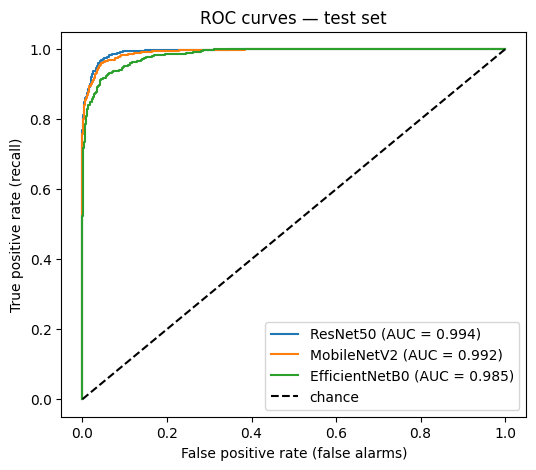

In [36]:
# Cell 28: ROC curves for all three models
plt.figure(figsize=(6, 5))
for name, (pv, pt) in preds.items():
    fpr, tpr, _ = roc_curve(yt, pt)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(yt, pt):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="chance")
plt.xlabel("False positive rate (false alarms)")
plt.ylabel("True positive rate (recall)")
plt.title("ROC curves — test set")
plt.legend(loc="lower right")
plt.savefig(f"{RES_DIR}/roc_curves.png", dpi=200, bbox_inches="tight")
plt.show()

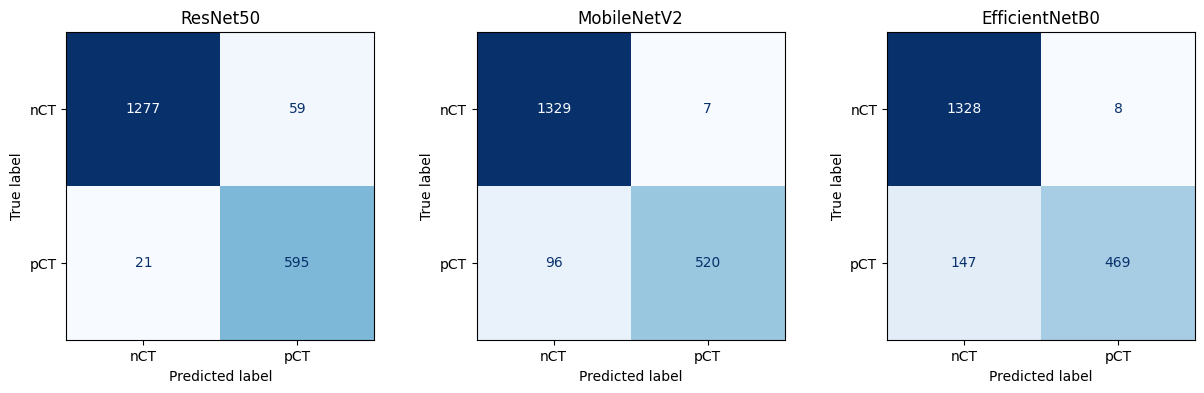

In [37]:
# Cell 29: confusion matrices (default threshold 0.5)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (name, (pv, pt)) in zip(ax, preds.items()):
    ConfusionMatrixDisplay.from_predictions(
        yt, (pt >= 0.5).astype(int), display_labels=["nCT", "pCT"],
        ax=a, colorbar=False, cmap="Blues")
    a.set_title(name)
plt.savefig(f"{RES_DIR}/confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()

In [38]:
# Cell 30: save per-image predictions (needed for Phase 5 and Phase 6)
out = test_g[["path", "label", "y", "group"]].copy()
for name, (pv, pt) in preds.items():
    out[f"prob_{name}"] = pt
out.to_csv(f"{RES_DIR}/test_predictions.csv", index=False)
print(out.head())

                                                path label  y  group  \
0  /content/data/Preprocessed CT scans/pCT/pCT281...   pCT  1     90   
1  /content/data/Preprocessed CT scans/pCT/pCT255...   pCT  1    111   
2  /content/data/Preprocessed CT scans/pCT/pCT232...   pCT  1    322   
3  /content/data/Preprocessed CT scans/pCT/pCT350...   pCT  1    215   
4  /content/data/Preprocessed CT scans/pCT/pCT169...   pCT  1    221   

   prob_ResNet50  prob_MobileNetV2  prob_EfficientNetB0  
0       1.000000          0.999668             0.999536  
1       0.948132          0.268924             0.073496  
2       0.999999          0.997559             0.971783  
3       1.000000          1.000000             1.000000  
4       0.999985          0.999956             0.496256  


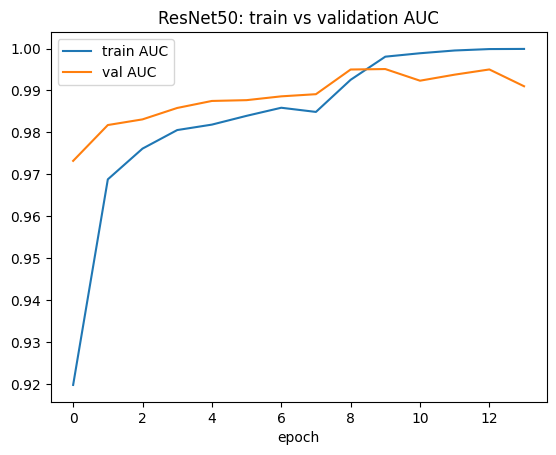

In [39]:
# Cell 31 (optional): overfitting check — training vs validation AUC for ResNet50
h = h_res
plt.plot(h["auc"], label="train AUC"); plt.plot(h["val_auc"], label="val AUC")
plt.xlabel("epoch"); plt.legend(); plt.title("ResNet50: train vs validation AUC")
plt.savefig(f"{RES_DIR}/resnet_train_vs_val.png", dpi=200, bbox_inches="tight")
plt.show()

In [40]:
# Cell 32: Grad-CAM function (works for any of the three models)
import matplotlib.pyplot as plt

# if the session reset, reload first (and re-run Cells 1-2, 10, 15):
# resnet = keras.models.load_model(f"{SAVE_DIR}/resnet50_best.keras")

def make_gradcam(model):
    base = next(l for l in model.layers if isinstance(l, keras.Model))   # the pretrained backbone
    i = model.layers.index(base)
    pre  = [l for l in model.layers[:i] if not isinstance(l, layers.InputLayer)]  # preprocessing
    head = model.layers[i + 1:]                                          # pooling, dropout, dense
    dense = head[-1]

    def run(img, sign=1):
        """img: (224,224,3) float32 in 0-255. sign=+1 → evidence for COVID, -1 → for normal."""
        x = tf.expand_dims(tf.cast(img, tf.float32), 0)
        for l in pre:
            x = l(x)
        with tf.GradientTape() as tape:
            feat = base(x, training=False)                    # (1, 7, 7, channels)
            tape.watch(feat)
            z = feat
            for l in head[:-1]:
                z = l(z)                                      # pooling + dropout (inference mode)
            logit = tf.matmul(z, dense.kernel) + dense.bias   # score BEFORE the sigmoid
            target = sign * logit
        grads = tape.gradient(target, feat)
        weights = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)    # importance per feature map
        cam = tf.nn.relu(tf.reduce_sum(weights * feat, axis=-1))[0]    # weighted sum + ReLU
        cam = cam / (tf.reduce_max(cam) + 1e-8)                        # scale to 0-1
        cam = tf.image.resize(cam[..., None], (224, 224), method="bilinear")[..., 0]
        return cam.numpy(), float(tf.sigmoid(logit)[0, 0])
    return run

gradcam_resnet = make_gradcam(resnet)
img, _ = load_image(test_g.path.iloc[0], 0)
cam, prob = gradcam_resnet(img)
print("heatmap shape:", cam.shape, "| P(COVID):", round(prob, 3), "| max:", cam.max())

heatmap shape: (224, 224) | P(COVID): 1.0 | max: 0.99340844


In [42]:
# Cell 33: plotting helper (original on top, overlay below)
def show_cams(run, rows, sign=1, save_as=None):
    n = len(rows)
    fig, ax = plt.subplots(2, n, figsize=(3.2 * n, 6.6))
    for j, (path, truth) in enumerate(rows):
        img, _ = load_image(path, 0)
        cam, prob = run(img, sign)
        g = img.numpy()[..., 0]
        g = g / max(g.max(), 1)                              # scale for display only
        ax[0, j].imshow(g, cmap="gray")
        ax[0, j].set_title(f"true: {truth}\nP(COVID) = {prob:.2f}", fontsize=9)
        ax[1, j].imshow(g, cmap="gray")
        ax[1, j].imshow(cam, cmap="jet", alpha=0.45, vmin=0, vmax=1)
        ax[1, j].set_title("Grad-CAM", fontsize=9)
        ax[0, j].axis("off"); ax[1, j].axis("off")
    plt.tight_layout()
    if save_as:
        plt.savefig(f"{RES_DIR}/{save_as}", dpi=200, bbox_inches="tight")
    plt.show()

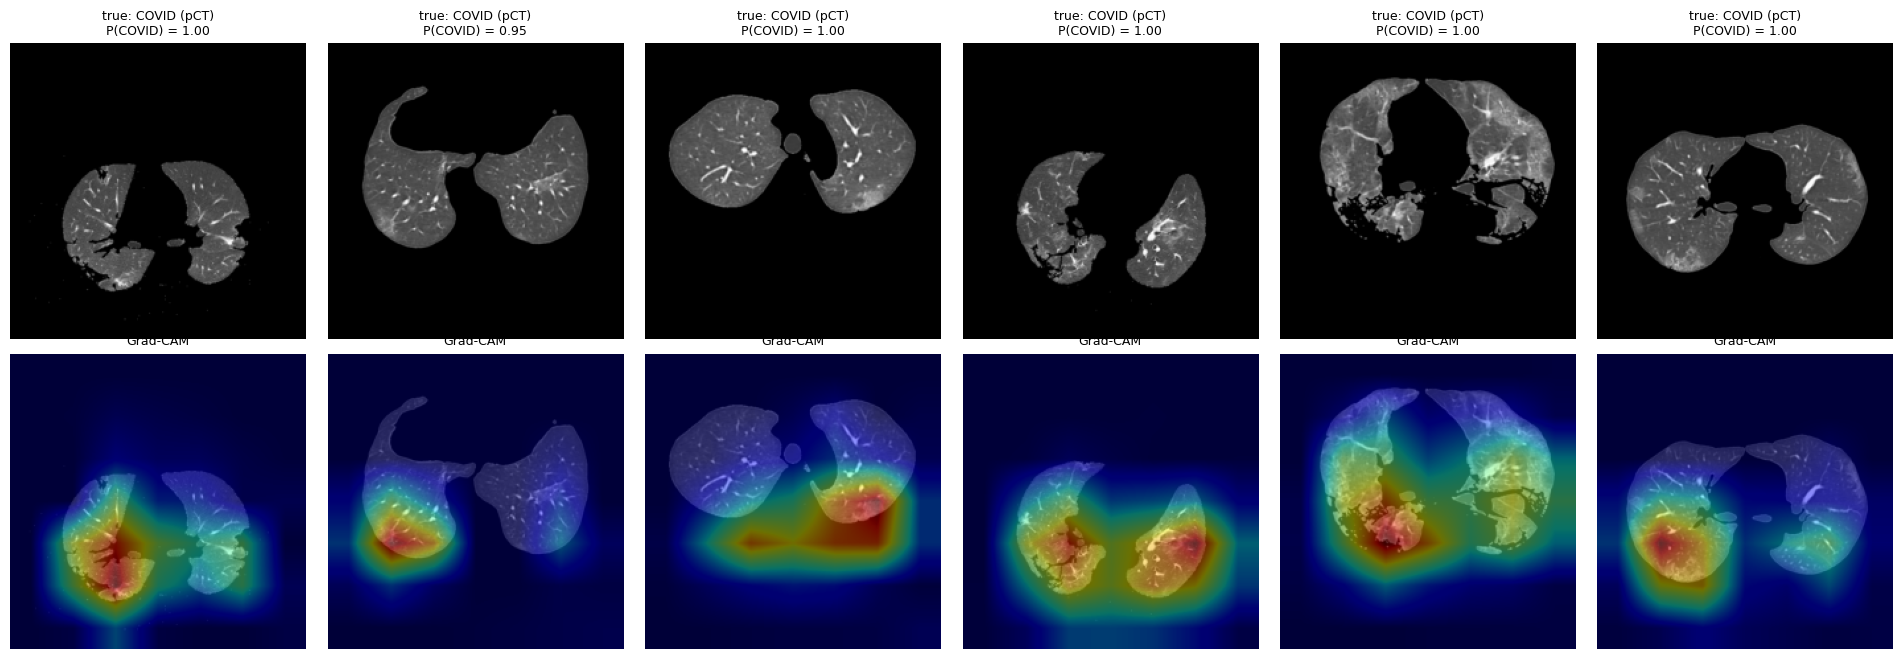

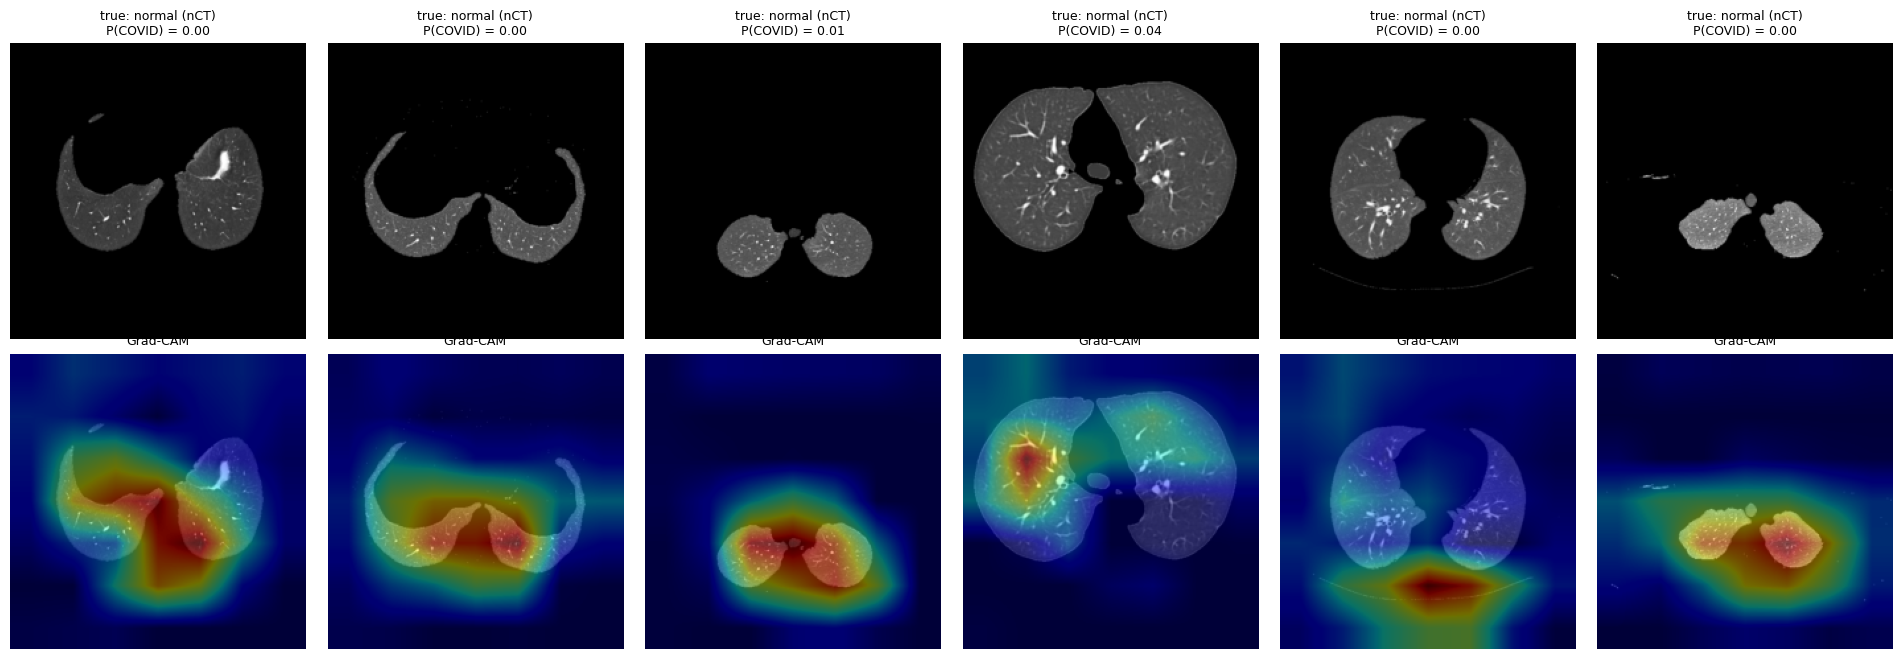

In [43]:
# Cell 34: random (NOT hand-picked) correct predictions from the test set
pred = pd.read_csv(f"{RES_DIR}/test_predictions.csv")
p = pred.prob_ResNet50

tp = pred[(pred.y == 1) & (p >= 0.5)].sample(6, random_state=1)
tn = pred[(pred.y == 0) & (p < 0.5)].sample(6, random_state=1)

show_cams(gradcam_resnet, [(r.path, "COVID (pCT)") for r in tp.itertuples()],
          sign=1, save_as="gradcam_true_positives.png")
show_cams(gradcam_resnet, [(r.path, "normal (nCT)") for r in tn.itertuples()],
          sign=-1, save_as="gradcam_true_negatives.png")

In [44]:
# Cell 35: numerical sanity check — how much of the heatmap lies on lung tissue?
def lung_focus(run, paths, sign=1):
    inside, area = [], []
    for pth in paths:
        img, _ = load_image(pth, 0)
        g = img.numpy()[..., 0]
        mask = (g > 10).astype("float32")[None, ..., None]
        mask = tf.nn.max_pool2d(mask, 9, 1, "SAME").numpy()[0, ..., 0] > 0   # slight dilation
        cam, _ = run(img, sign)
        if cam.sum() > 0:
            inside.append(cam[mask].sum() / cam.sum())
            area.append(mask.mean())
    return np.mean(inside), np.mean(area), len(inside)

tp_all = pred[(pred.y == 1) & (p >= 0.5)].sample(150, random_state=2)
frac, area, n = lung_focus(gradcam_resnet, tp_all.path.tolist())
print(f"Heatmap mass inside lungs: {frac:.1%}  |  lungs cover {area:.1%} of the image  |  n = {n}")

Heatmap mass inside lungs: 56.0%  |  lungs cover 25.9% of the image  |  n = 150


In [45]:
# Cell 36: two diagnostics for the heatmaps
def lung_mask_of(g, dil=9):
    m = (g > 10).astype("float32")[None, ..., None]
    return tf.nn.max_pool2d(m, dil, 1, "SAME").numpy()[0, ..., 0] > 0

# (a) Control for coarseness: how much would a PERFECTLY lung-focused 7x7 map put inside the lungs?
def coarse_baseline(mask):
    m = tf.constant(mask.astype("float32")[None, ..., None])
    small = tf.image.resize(m, (7, 7), method="area")
    big = tf.image.resize(small, (224, 224), method="bilinear").numpy()[0, ..., 0]
    return big[mask].sum() / (big.sum() + 1e-8)

ctrl = []
for pth in tp_all.path.tolist():
    img, _ = load_image(pth, 0)
    ctrl.append(coarse_baseline(lung_mask_of(img.numpy()[..., 0])))
print(f"Ideal lung-focused 7x7 map would keep {np.mean(ctrl):.1%} inside the lungs "
      f"(your model: {frac:.1%})")

# (b) Vertical position of the heatmap centre: 0 = top of lung region, 1 = bottom
def vertical_position(run, paths, sign=1):
    out = []
    for pth in paths:
        img, _ = load_image(pth, 0)
        g = img.numpy()[..., 0]
        rows = np.where((g > 10).sum(axis=1) >= 3)[0]
        if len(rows) < 10:
            continue
        cam, _ = run(img, sign)
        if cam.sum() == 0:
            continue
        cy = (cam.sum(axis=1) * np.arange(224)).sum() / cam.sum()
        out.append((cy - rows.min()) / max(rows.max() - rows.min(), 1))
    return np.array(out)

tn_all = pred[(pred.y == 0) & (p < 0.5)].sample(100, random_state=2)
pos_tp = vertical_position(gradcam_resnet, tp_all.path.tolist()[:100], sign=1)
pos_tn = vertical_position(gradcam_resnet, tn_all.path.tolist(), sign=1)
print(f"COVID images : median vertical position {np.median(pos_tp):.2f}  (n={len(pos_tp)})")
print(f"Normal images: median vertical position {np.median(pos_tn):.2f}  (n={len(pos_tn)})")
print("Share of heat centres BELOW the lung region (>1.0):",
      f"COVID {np.mean(pos_tp > 1):.0%} | normal {np.mean(pos_tn > 1):.0%}")

Ideal lung-focused 7x7 map would keep 68.2% inside the lungs (your model: 56.0%)
COVID images : median vertical position 0.73  (n=100)
Normal images: median vertical position 0.82  (n=98)
Share of heat centres BELOW the lung region (>1.0): COVID 3% | normal 42%


In [46]:
# Cell 37: error table for the primary model (ResNet50 at threshold 0.5) + simple image descriptors
pred = pd.read_csv(f"{RES_DIR}/test_predictions.csv")
pred["p"] = pred.prob_ResNet50
pred["pred"] = (pred.p >= 0.5).astype(int)
pred["outcome"] = np.select(
    [(pred.y == 1) & (pred.pred == 1), (pred.y == 0) & (pred.pred == 0), (pred.y == 0) & (pred.pred == 1)],
    ["TP", "TN", "FP"], default="FN")
print(pred.outcome.value_counts().to_dict())          # expect TP 595, TN 1277, FP 59, FN 21

areas = []
for pth in pred.path:
    img, _ = load_image(pth, 0)
    areas.append((img.numpy()[..., 0] > 10).mean())    # fraction of the image occupied by lung tissue
pred["lung_area"] = areas
pred.to_csv(f"{RES_DIR}/test_predictions_ext.csv", index=False)

{'TN': 1277, 'TP': 595, 'FP': 59, 'FN': 21}


In [47]:
# Cell 38: do errors depend on how much lung is visible, and do they cluster in a few image groups?
pred["area_bin"] = pd.qcut(pred.lung_area, 3, labels=["small lung area", "medium", "large"])
rows = []
for b, d in pred.groupby("area_bin", observed=True):
    rows.append({"lung size": b, "n": len(d),
                 "missed-case rate (FN / COVID)": round((d.outcome == "FN").sum() / max((d.y == 1).sum(), 1), 3),
                 "false-alarm rate (FP / normal)": round((d.outcome == "FP").sum() / max((d.y == 0).sum(), 1), 3)})
print(pd.DataFrame(rows).to_string(index=False))

err = pred[pred.outcome.isin(["FP", "FN"])]
by_g = err.groupby("group").size().sort_values(ascending=False)
print(f"\nErrors fall in {len(by_g)} of {pred.group.nunique()} groups; "
      f"the top 5 groups hold {by_g.head(5).sum()} of {len(err)} errors")

      lung size   n  missed-case rate (FN / COVID)  false-alarm rate (FP / normal)
small lung area 651                          0.019                           0.018
         medium 650                          0.013                           0.010
          large 651                          0.061                           0.114

Errors fall in 18 of 53 groups; the top 5 groups hold 49 of 80 errors


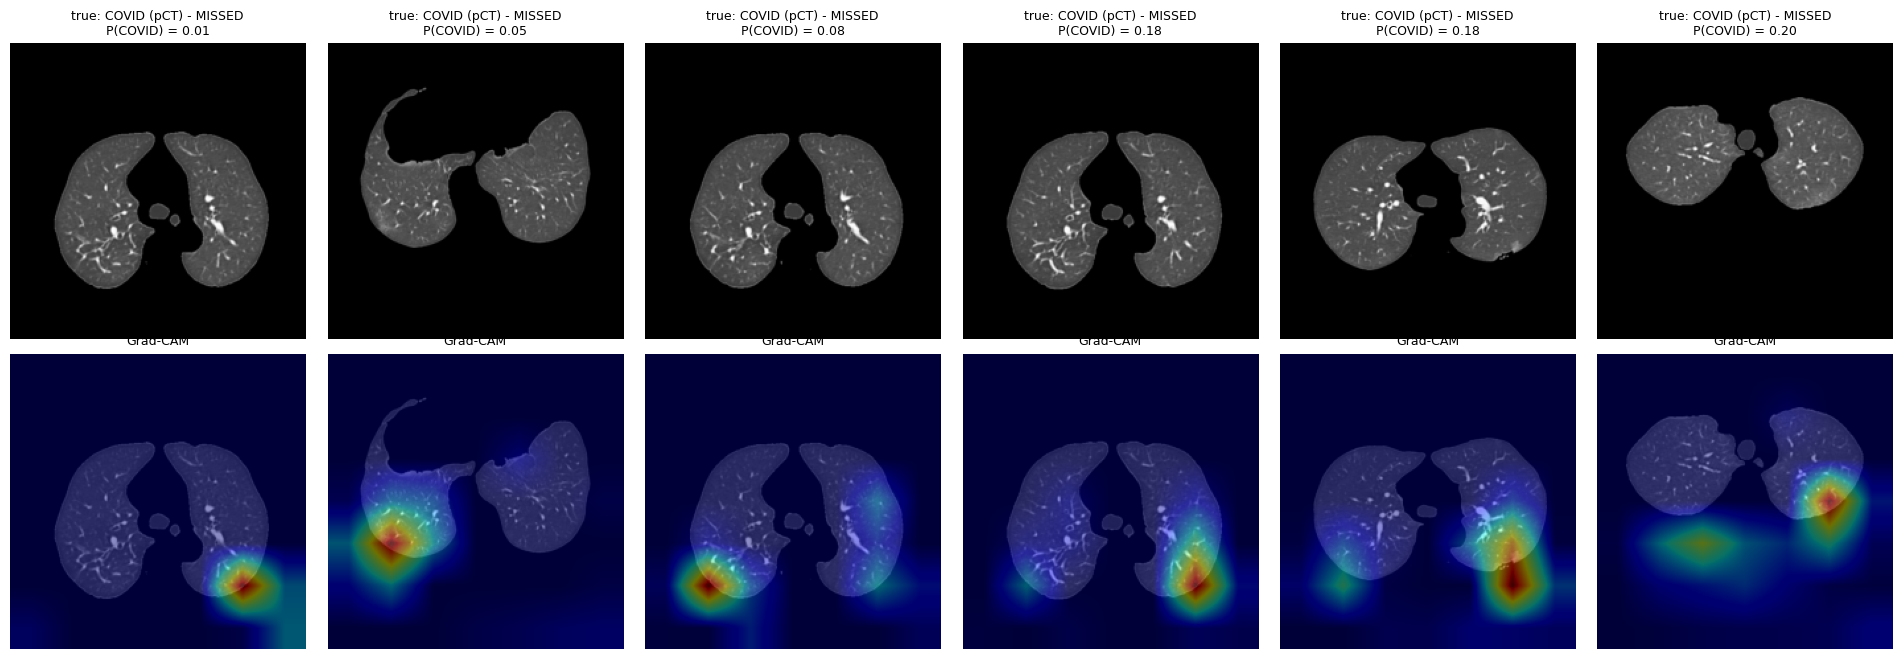

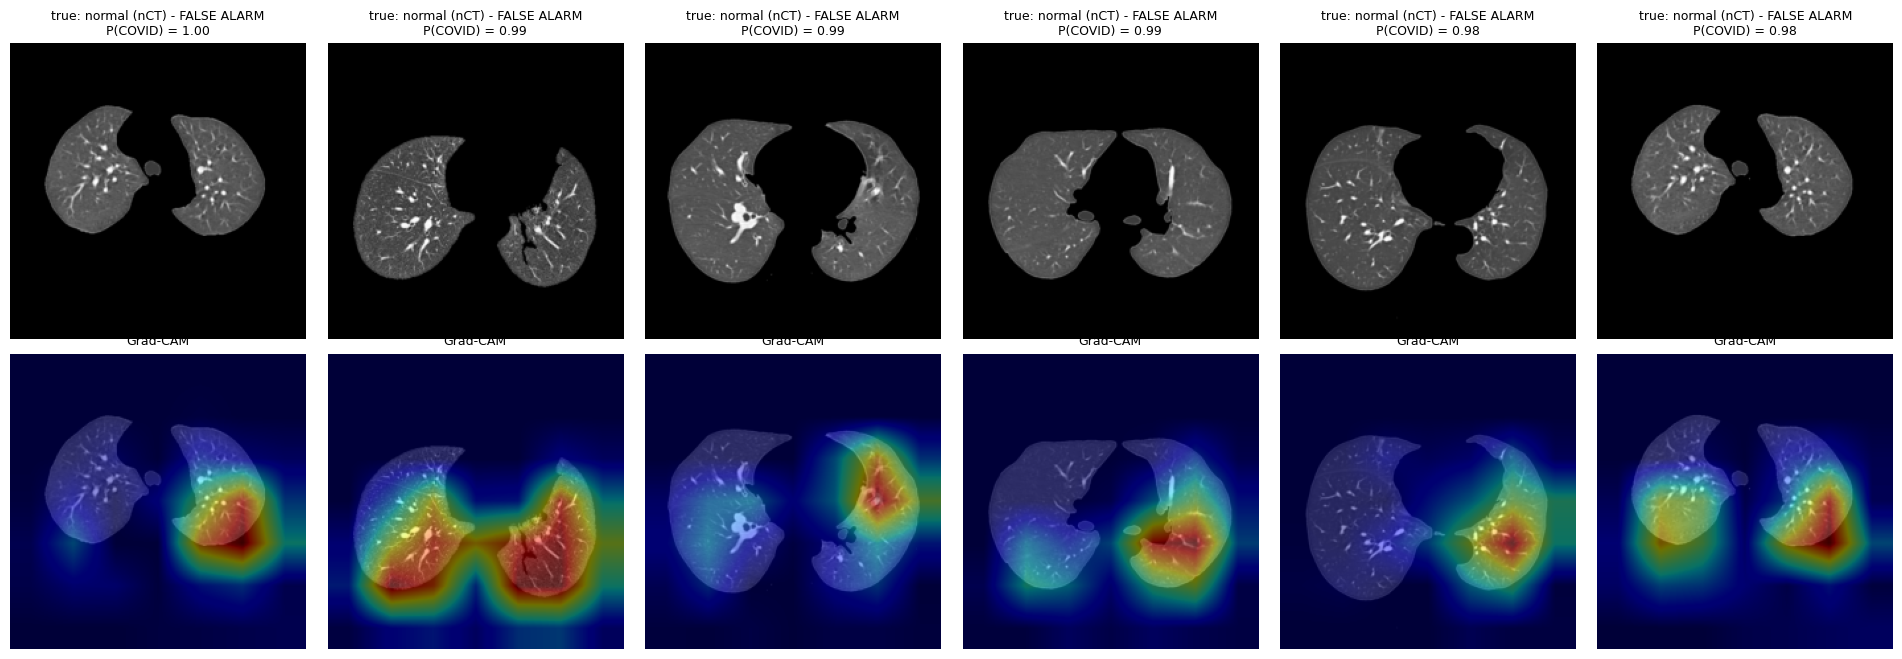

In [48]:
# Cell 39: the most confident mistakes, with Grad-CAM (evidence-for-COVID heatmap for both)
fn = pred[pred.outcome == "FN"].sort_values("p").head(6)                    # surest "normal" on a COVID slice
fp = pred[pred.outcome == "FP"].sort_values("p", ascending=False).head(6)   # surest "COVID" on a normal slice

show_cams(gradcam_resnet, [(r.path, "COVID (pCT) - MISSED") for r in fn.itertuples()],
          sign=1, save_as="errors_false_negatives.png")
show_cams(gradcam_resnet, [(r.path, "normal (nCT) - FALSE ALARM") for r in fp.itertuples()],
          sign=1, save_as="errors_false_positives.png")

In [49]:
# Cell 40: mistakes shared by all three models (candidates for label noise or genuinely hard slices)
cols = ["prob_ResNet50", "prob_MobileNetV2", "prob_EfficientNetB0"]
wrong = pd.concat([((pred[c] >= 0.5).astype(int) != pred.y) for c in cols], axis=1)
wrong.columns = ["ResNet50", "MobileNetV2", "EfficientNetB0"]
print("Wrong in all three models:", int(wrong.all(axis=1).sum()))
print("Wrong ONLY in ResNet50  :", int((wrong.ResNet50 & ~wrong.MobileNetV2 & ~wrong.EfficientNetB0).sum()))
print("Wrong in at least one   :", int(wrong.any(axis=1).sum()))

Wrong in all three models: 20
Wrong ONLY in ResNet50  : 50
Wrong in at least one   : 218


In [50]:
# Cell 41: a screening-oriented threshold, chosen on VALIDATION (recall >= 98%), reported on test
pv, pt = preds["ResNet50"]
fpr_v, tpr_v, thr_v = roc_curve(yv, pv)
t98 = float(thr_v[np.argmax(tpr_v >= 0.98)])         # highest threshold that reaches 98% recall on validation

cmp = pd.DataFrame([
    {"setting": "default 0.5",           **metrics_at(yt, pt, 0.5)},
    {"setting": "recall>=98% on val",    **metrics_at(yt, pt, t98)}])
print(cmp[["setting", "threshold", "recall", "specificity", "precision", "FN", "FP"]].round(4).to_string(index=False))

           setting  threshold  recall  specificity  precision  FN  FP
       default 0.5      0.500  0.9659       0.9558     0.9098  21  59
recall>=98% on val      0.303  0.9838       0.9296     0.8657  10  94


small lung area  AUC = 0.9990 | COVID share = 0.324 | n = 651
medium           AUC = 0.9996 | COVID share = 0.245 | n = 650
large            AUC = 0.9783 | COVID share = 0.378 | n = 651
outcome  FN  FP  images in group
group                           
8         0  10               28
82        0   5               30
104       4   6               61
213       0  11               27
352       5   8               54


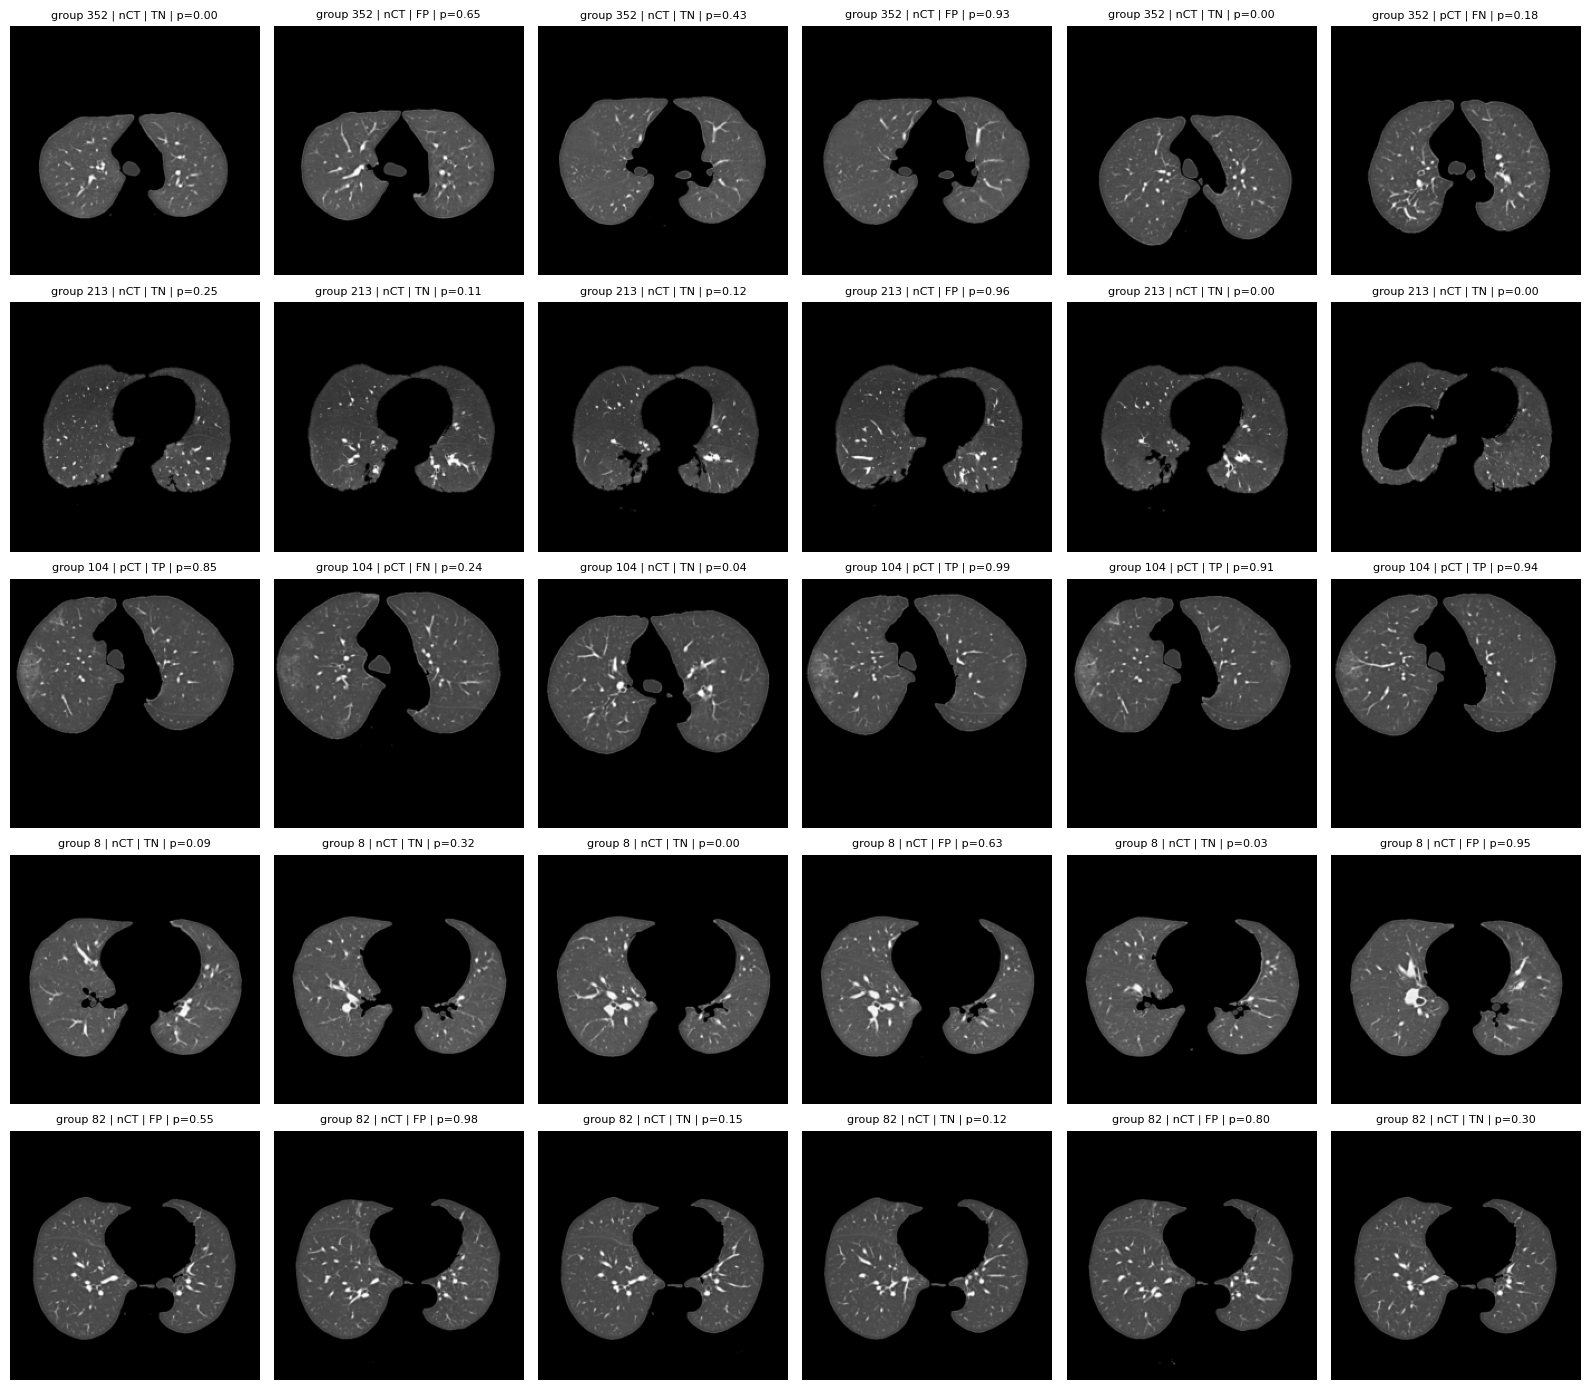

In [51]:
# Cell 42: where do errors cluster?
# (a) AUC and COVID share inside each lung-size bin (AUC doesn't depend on the threshold)
for b, d in pred.groupby("area_bin", observed=True):
    print(f"{b:16s} AUC = {roc_auc_score(d.y, d.p):.4f} | COVID share = {d.y.mean():.3f} | n = {len(d)}")

# (b) look inside the 5 groups holding most errors
top = by_g.head(5).index.tolist()
summary = err[err.group.isin(top)].groupby(["group", "outcome"]).size().unstack(fill_value=0)
summary["images in group"] = pred.groupby("group").size().loc[summary.index]
print(summary)

fig, ax = plt.subplots(5, 6, figsize=(16, 14))
for a in ax.ravel():
    a.axis("off")
for r, g in enumerate(top):
    d = pred[pred.group == g]
    d = d.sample(min(6, len(d)), random_state=0)          # random members, right and wrong alike
    for c, row in enumerate(d.itertuples()):
        img, _ = load_image(row.path, 0)
        im = img.numpy()[..., 0]
        ax[r, c].imshow(im / max(im.max(), 1), cmap="gray")
        ax[r, c].set_title(f"group {g} | {row.label} | {row.outcome} | p={row.p:.2f}", fontsize=8)
plt.tight_layout()
plt.savefig(f"{RES_DIR}/top_error_groups.png", dpi=200, bbox_inches="tight")
plt.show()

In [52]:
# Cell 43: prepare Phase 7 — lean model files and the exact library versions
import sys, keras
print("python", sys.version.split()[0], "| tensorflow", tf.__version__, "| keras", keras.__version__)

APP_DIR = f"{SAVE_DIR}/app_models"
os.makedirs(APP_DIR, exist_ok=True)
for name, m in {"resnet50": resnet, "mobilenetv2": mobilenet}.items():
    m.compile(optimizer="sgd", loss="binary_crossentropy")   # drops Adam's large state → smaller file
    m.save(f"{APP_DIR}/{name}_covid.keras")
    print(name, round(os.path.getsize(f"{APP_DIR}/{name}_covid.keras") / 1e6, 1), "MB")

python 3.13.15 | tensorflow 2.21.0 | keras 3.13.2
resnet50 95.0 MB
mobilenetv2 9.6 MB


In [58]:
# Cell 44: download models + 6 random test images for trying the app
import shutil
from google.colab import files

files.download(f"{APP_DIR}/resnet50_covid.keras")
files.download(f"{APP_DIR}/mobilenetv2_covid.keras")

SAMPLE_DIR = "/content/app_samples"
os.makedirs(SAMPLE_DIR, exist_ok=True)
for lbl, k in [("pCT", 3), ("nCT", 3)]:
    for r in pred[pred.label == lbl].sample(k, random_state=7).itertuples():
        shutil.copy(r.path, f"{SAMPLE_DIR}/{lbl}_{os.path.basename(r.path)}")
shutil.make_archive("/content/app_samples", "zip", SAMPLE_DIR)
files.download("/content/app_samples.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
# Cell 45: ensembles (choose by VALIDATION, report on test)
combos = {
    "ResNet50 + MobileNetV2": ["ResNet50", "MobileNetV2"],
    "All three":              ["ResNet50", "MobileNetV2", "EfficientNetB0"],
}
rows = []
for label, members in combos.items():
    ev = np.mean([preds[m][0] for m in members], axis=0)
    et = np.mean([preds[m][1] for m in members], axis=0)
    t = best_f1_threshold(yv, ev)                     # threshold chosen on validation
    for tl, thr in [("0.5", 0.5), ("val-tuned", t)]:
        rows.append({"model": label, "val AUC": roc_auc_score(yv, ev),
                     "threshold_type": tl, **metrics_at(yt, et, thr)})
# single ResNet50 for comparison
for tl, thr in [("0.5", 0.5), ("val-tuned", best_f1_threshold(yv, preds["ResNet50"][0]))]:
    rows.append({"model": "ResNet50 alone", "val AUC": roc_auc_score(yv, preds["ResNet50"][0]),
                 "threshold_type": tl, **metrics_at(yt, preds["ResNet50"][1], thr)})
ens = pd.DataFrame(rows).round(4)
ens[["model", "threshold_type", "val AUC", "auc", "precision", "recall", "specificity", "f1", "FN", "FP"]]

,model,threshold_type,val AUC,auc,precision,recall,specificity,f1,FN,FP
0,ResNet50 + MobileNetV2,0.5,0.9955,0.9953,0.9807,0.9075,0.9918,0.9427,57,11
1,ResNet50 + MobileNetV2,val-tuned,0.9955,0.9953,0.9807,0.9075,0.9918,0.9427,57,11
2,All three,0.5,0.9947,0.9956,0.9851,0.8571,0.9940,0.9167,88,8
3,All three,val-tuned,0.9947,0.9956,0.9868,0.8506,0.9948,0.9137,92,7
4,ResNet50 alone,0.5,0.9961,0.9944,0.9098,0.9659,0.9558,0.9370,21,59
5,ResNet50 alone,val-tuned,0.9961,0.9944,0.9285,0.9481,0.9663,0.9382,32,45


raw                  ECE = 0.0305 | Brier = 0.0319
calibrated (Platt)   ECE = 0.0124 | Brier = 0.0283


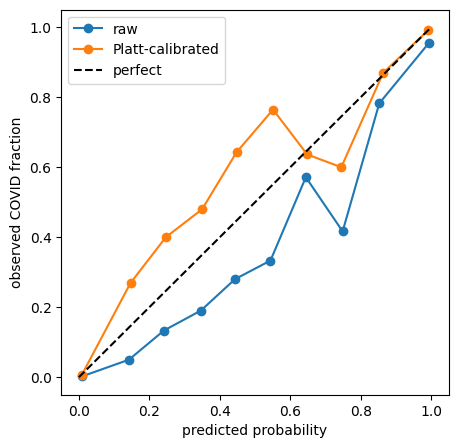

In [60]:
# Cell 46: calibration of ResNet50 (fit on VALIDATION, evaluate on TEST)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p))

def ece(y, p, bins=10):
    edges = np.linspace(0, 1, bins + 1); e = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (p >= lo) & ((p < hi) if hi < 1 else (p <= hi))
        if m.sum():
            e += m.mean() * abs(y[m].mean() - p[m].mean())
    return e

pv, pt = preds["ResNet50"]
platt = LogisticRegression(C=1e6).fit(logit(pv).reshape(-1, 1), yv)    # 2 parameters: slope + shift
pt_cal = platt.predict_proba(logit(pt).reshape(-1, 1))[:, 1]

for name, p_ in [("raw", pt), ("calibrated (Platt)", pt_cal)]:
    print(f"{name:20s} ECE = {ece(yt, p_):.4f} | Brier = {brier_score_loss(yt, p_):.4f}")

# reliability diagram
fig, ax = plt.subplots(figsize=(5, 5))
for name, p_ in [("raw", pt), ("Platt-calibrated", pt_cal)]:
    bins = np.linspace(0, 1, 11); xs, ys = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (p_ >= lo) & (p_ <= hi)
        if m.sum() >= 10:
            xs.append(p_[m].mean()); ys.append(yt[m].mean())
    ax.plot(xs, ys, marker="o", label=name)
ax.plot([0, 1], [0, 1], "k--", label="perfect")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed COVID fraction"); ax.legend()
plt.savefig(f"{RES_DIR}/reliability_resnet50.png", dpi=200, bbox_inches="tight")
plt.show()